In [1]:
# Run garbage collection
import gc
gc.collect()

0

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import logging
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [3]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [4]:
path_load = './data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| z_train   | (17418, 23)       |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| z_test    | (2198, 23)        |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+
| z_val     | (2183, 23)        |
+-----------+-------------------+


In [5]:
classes_label = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
#print(classes_label.columns[1:])
label_map = {label: i for i, label in enumerate(classes_label.columns[1:])}
print(label_map)

subclasses_label = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
#print(subclasses_label.columns[1:])
label_map_sub = {label: i for i, label in enumerate(subclasses_label.columns[1:])}
print(label_map_sub)

label_map = {
 'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4
}

label_map_sub = {
 'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4,
 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10,
 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15,
 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20,
 'STTC': 21, 'NST_': 22
}

superclass_dict = {
    'NORM': ['NORM'],
    'CD': ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
    'HYP': ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI': ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_']
}

{'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
{'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4, 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10, 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15, 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20, 'STTC': 21, 'NST_': 22}


+------------+---------+--------------+--------+---------+
| Subclass   |   Train |   Validation |   Test |   Total |
+============+=========+==============+========+=========+
| NORM       |    7596 |          955 |    963 |    9514 |
+------------+---------+--------------+--------+---------+
| CD         |    3907 |          495 |    496 |    4898 |
+------------+---------+--------------+--------+---------+
| HYP        |    2119 |          268 |    262 |    2649 |
+------------+---------+--------------+--------+---------+
| MI         |    4379 |          540 |    550 |    5469 |
+------------+---------+--------------+--------+---------+
| STTC       |    4186 |          528 |    521 |    5235 |
+------------+---------+--------------+--------+---------+


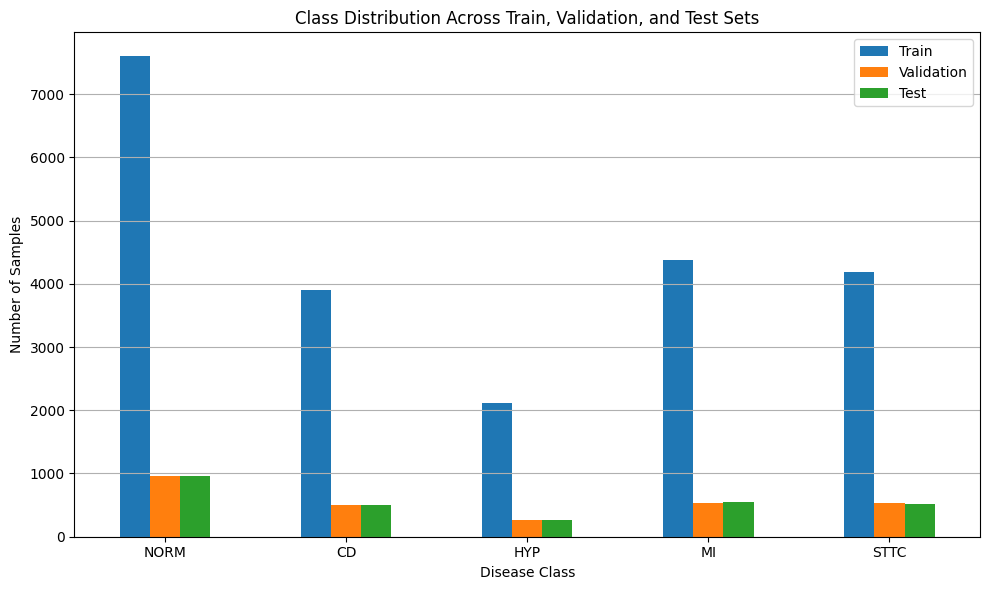

In [6]:
index_to_label = {v: k for k, v in label_map.items()}
# Convert one-hot to class labels
# num_classes = y_train.shape[1]  # Assuming y_train is the one-hot encoded matrix
# y_train_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_train], dtype=int)
# y_val_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_val], dtype=int)
# y_test_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_test], dtype=int)
num_y_train = np.sum(y_train, axis=0, dtype=int)
num_y_val = np.sum(y_val, axis=0, dtype=int)
num_y_test = np.sum(y_test, axis=0, dtype=int)


# Align the indices (classes 0–4)
all_classes = range(len(label_map))


# Prepare table for tabulate
table = []
for idx in all_classes:
    label = index_to_label[idx]
    table.append([label, num_y_train[idx], num_y_val[idx], num_y_test[idx], num_y_train[idx] + num_y_val[idx] + num_y_test[idx]])

from tabulate import tabulate
print(tabulate(table, headers=["Subclass", "Train", "Validation", "Test", "Total"], tablefmt="grid"))
# Combine into DataFrame for plotting
df = pd.DataFrame({
    'Train': num_y_train,
    'Validation': num_y_val,
    'Test': num_y_test
})
df.index = df.index.map(index_to_label)

# Plot
plt.figure(figsize=(10, 6))  # Width=10, Height=6
df.plot(kind='bar', ax=plt.gca())
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

+------------+---------+--------------+--------+---------+
| Subclass   |   Train |   Validation |   Test |   Total |
+============+=========+==============+========+=========+
| NORM       |    7596 |          955 |    963 |    9514 |
+------------+---------+--------------+--------+---------+
| LAFB/LPFB  |    1437 |          181 |    179 |    1797 |
+------------+---------+--------------+--------+---------+
| IRBBB      |     894 |          112 |    112 |    1118 |
+------------+---------+--------------+--------+---------+
| ILBBB      |      62 |            7 |      8 |      77 |
+------------+---------+--------------+--------+---------+
| CLBBB      |     428 |           54 |     54 |     536 |
+------------+---------+--------------+--------+---------+
| CRBBB      |     432 |           55 |     54 |     541 |
+------------+---------+--------------+--------+---------+
| _AVB       |     658 |           83 |     82 |     823 |
+------------+---------+--------------+--------+--------

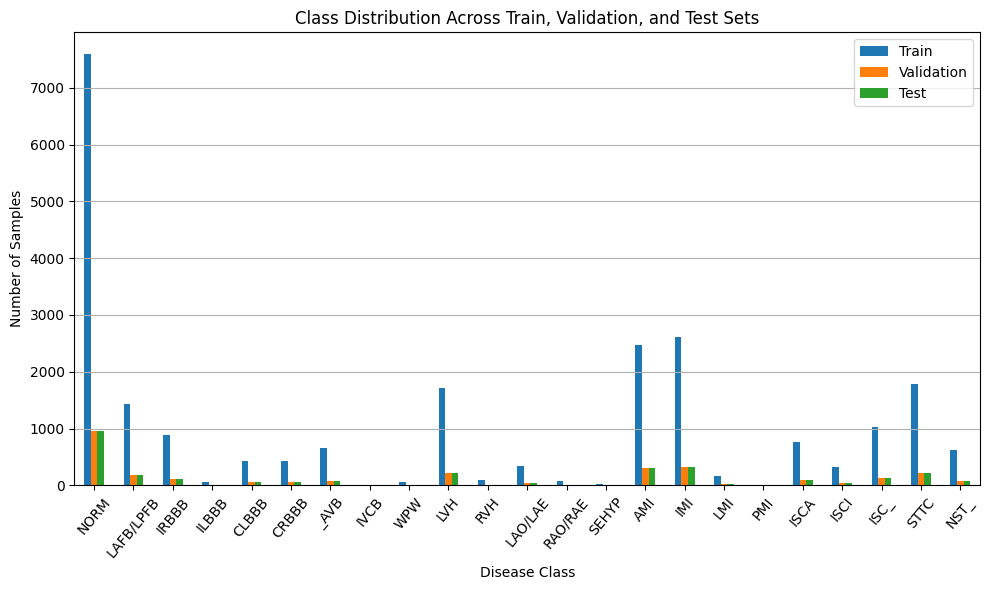

In [7]:
index_to_sub_label = {v: k for k, v in label_map_sub.items()}
# Convert one-hot to class labels
# num_classes = y_train.shape[1]  # Assuming y_train is the one-hot encoded matrix
# y_train_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_train], dtype=int)
# y_val_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_val], dtype=int)
# y_test_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_test], dtype=int)
num_z_train = np.sum(z_train, axis=0, dtype=int)
num_z_val = np.sum(z_val, axis=0, dtype=int)
num_z_test = np.sum(z_test, axis=0, dtype=int)


# Align the indices (classes 0–4)
all_classes = range(len(label_map_sub))


# Prepare table for tabulate
table = []
for idx in all_classes:
    label = index_to_sub_label[idx]
    table.append([label, num_z_train[idx], num_z_val[idx], num_z_test[idx], num_z_train[idx] + num_z_val[idx] + num_z_test[idx]])

from tabulate import tabulate
print(tabulate(table, headers=["Subclass", "Train", "Validation", "Test", "Total"], tablefmt="grid"))
# Combine into DataFrame for plotting
df = pd.DataFrame({
    'Train': num_z_train,
    'Validation': num_z_val,
    'Test': num_z_test,
})
df.index = df.index.map(index_to_sub_label)

# Plot
plt.figure(figsize=(10, 6))  # Width=10, Height=6
df.plot(kind='bar', ax=plt.gca())
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=50)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [8]:

# Identify the subclasses with low F1-Score
low_f1_subclasses = ["IVCB", "RVH", "SEHYP", "PMI"]

# Function to remove samples based on the low F1-Score subclasses
def remove_low_f1_samples(X, y, z, low_f1_subclasses, label_map_sub):
    # Find the indices to remove based on the low F1-Score subclasses
    to_remove_indices = []
    
    # Iterate over each sample
    for i in range(z.shape[0]):  # Iterate through the samples
        # Check if the sample has a low F1-Score subclass
        sample_labels = [label_map_sub[label] for label in low_f1_subclasses if label in label_map_sub]
        
        if any(z[i, label] == 1 for label in sample_labels):
            to_remove_indices.append(i)
    updated_label_map_sub = {k: v for k, v in label_map_sub.items() if k not in low_f1_subclasses}
    low_index = [label_map_sub[i] for i in low_f1_subclasses]
    # Remove the identified indices from X, y, and z
    X_filtered = np.delete(X, to_remove_indices, axis=0)
    y_filtered = np.delete(y, to_remove_indices, axis=0)
    z_filtered = np.delete(z, to_remove_indices, axis=0)
    z_filtered = np.delete(z_filtered, low_index, axis=1)
    return X_filtered, y_filtered, z_filtered, updated_label_map_sub

# Example usage: Remove samples where the F1-Score of the subclasses in `low_f1_subclasses` is below the threshold

# Assuming you already have X_train, y_train, z_train, X_test, y_test, z_test, etc.
X_train_filtered, y_train_filtered, z_train_filtered, label_map_sub_filtered  = remove_low_f1_samples(X_train, y_train, z_train, low_f1_subclasses, label_map_sub)
X_test_filtered, y_test_filtered, z_test_filtered, _ = remove_low_f1_samples(X_test, y_test, z_test, low_f1_subclasses, label_map_sub)
X_val_filtered, y_val_filtered, z_val_filtered, _ = remove_low_f1_samples(X_val, y_val, z_val, low_f1_subclasses, label_map_sub)

# The filtered datasets are now updated
print("Original datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}, z_train: {z_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}, z_test: {z_test.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}, z_train: {z_val.shape}")
print("Filtered datasets:")
print(f"X_train: {X_train_filtered.shape}, y_train: {y_train_filtered.shape}, z_train: {z_train_filtered.shape}")
print(f"X_test: {X_test_filtered.shape}, y_test: {y_test_filtered.shape}, z_test: {z_test_filtered.shape}")
print(f"X_val: {X_val_filtered.shape}, y_val: {y_val_filtered.shape}, z_train: {z_val_filtered.shape}")
label_map_sub = label_map_sub_filtered
label_map_sub = {label: idx for idx, label in enumerate(label_map_sub.keys())}

Original datasets:
X_train: (17418, 1000, 12), y_train: (17418, 5), z_train: (17418, 23)
X_test: (2198, 1000, 12), y_test: (2198, 5), z_test: (2198, 23)
X_val: (2183, 1000, 12), y_val: (2183, 5), z_train: (2183, 23)
Filtered datasets:
X_train: (17280, 1000, 12), y_train: (17280, 5), z_train: (17280, 19)
X_test: (2182, 1000, 12), y_test: (2182, 5), z_test: (2182, 19)
X_val: (2166, 1000, 12), y_val: (2166, 5), z_train: (2166, 19)


+------------+---------+--------------+--------+---------+
| Subclass   |   Train |   Validation |   Test |   Total |
+============+=========+==============+========+=========+
| NORM       |    7596 |          955 |    963 |    9514 |
+------------+---------+--------------+--------+---------+
| LAFB/LPFB  |    1392 |          179 |    170 |    1741 |
+------------+---------+--------------+--------+---------+
| IRBBB      |     848 |          102 |    108 |    1058 |
+------------+---------+--------------+--------+---------+
| ILBBB      |      62 |            7 |      8 |      77 |
+------------+---------+--------------+--------+---------+
| CLBBB      |     427 |           54 |     54 |     535 |
+------------+---------+--------------+--------+---------+
| CRBBB      |     387 |           52 |     50 |     489 |
+------------+---------+--------------+--------+---------+
| _AVB       |     651 |           81 |     79 |     811 |
+------------+---------+--------------+--------+--------

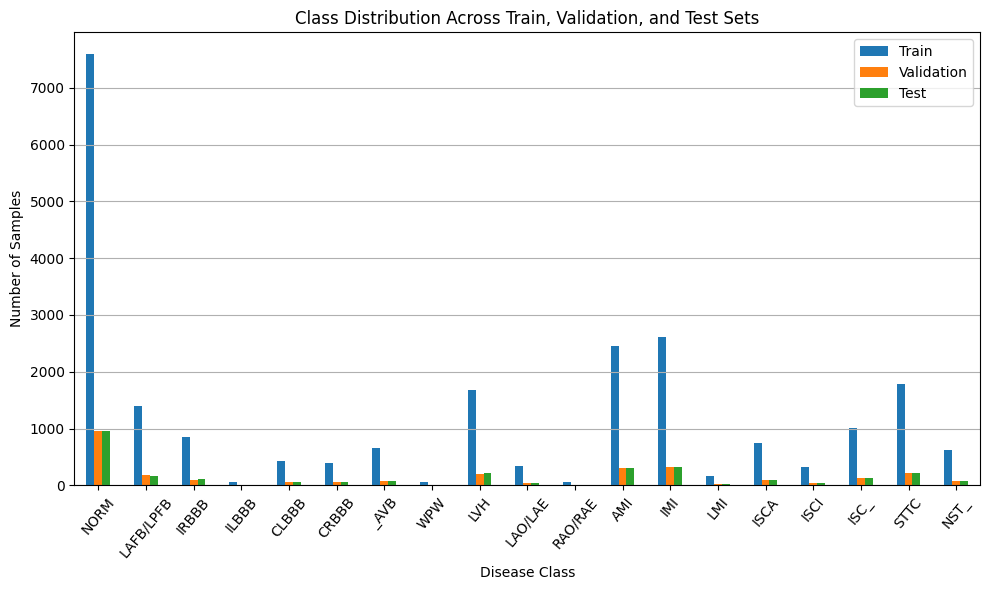

In [9]:
index_to_sub_label = {v: k for k, v in label_map_sub.items()}
# Convert one-hot to class labels
# num_classes = y_train.shape[1]  # Assuming y_train is the one-hot encoded matrix
# y_train_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_train], dtype=int)
# y_val_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_val], dtype=int)
# y_test_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_test], dtype=int)
num_z_train = np.sum(z_train_filtered, axis=0, dtype=int)
num_z_val = np.sum(z_val_filtered, axis=0, dtype=int)
num_z_test = np.sum(z_test_filtered, axis=0, dtype=int)


# Align the indices (classes 0–4)
all_classes = range(len(label_map_sub))


# Prepare table for tabulate
table = []
for idx in all_classes:
    label = index_to_sub_label[idx]
    table.append([label, num_z_train[idx], num_z_val[idx], num_z_test[idx], num_z_train[idx] + num_z_val[idx] + num_z_test[idx]])

from tabulate import tabulate
print(tabulate(table, headers=["Subclass", "Train", "Validation", "Test", "Total"], tablefmt="grid"))
# Combine into DataFrame for plotting
df = pd.DataFrame({
    'Train': num_z_train,
    'Validation': num_z_val,
    'Test': num_z_test,
})
df.index = df.index.map(index_to_sub_label)

# Plot
plt.figure(figsize=(10, 6))  # Width=10, Height=6
df.plot(kind='bar', ax=plt.gca())
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=50)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [34]:
def replicate_sample(sample, number_of_target_sample, list_of_target_class):
    x, y, z = [s for s in sample]
    print(z.shape)
    for i, cls in enumerate(list_of_target_class):
        print(f"Cls {cls}, {i}")
        class_indices = np.where(z == i)[0]
        n_class = len(class_indices)
    
        if n_class == 0:
            print(f"Warning: No samples found for class '{cls}'!")
            continue
        n_needed = number_of_target_sample - n_class
        if n_needed <= 0:
            print(f"Warning: No samples found for class '{cls}'!")
            continue
        else:
            # Randomly sample with replacement
            extra_indices = np.random.choice(class_indices, size=n_needed, replace=True)
            # Get extra samples
            X_extra = x[extra_indices]
            y_extra = y[extra_indices]
            z_extra = z[extra_indices]
            # Add to test set
            x = np.concatenate([x, X_extra], axis=0)
            y = np.concatenate([y, y_extra], axis=0)
            z = np.concatenate([z, z_extra], axis=0)
        print(f"Class {cls} has {n_class} samples, added {n_needed} extra samples, total {len(np.where(z == cls)[0])} samples")
    return x, y, z

In [36]:
label_list = list(label_map_sub.keys())
print(f"Label list: {label_list}")
x_resampled, y_resampled, z_resampled = replicate_sample([X_train_filtered, y_train_filtered, z_train_filtered], 100, label_list)

Label list: ['NORM', 'LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'WPW', 'LVH', 'LAO/LAE', 'RAO/RAE', 'AMI', 'IMI', 'LMI', 'ISCA', 'ISCI', 'ISC_', 'STTC', 'NST_']
(17280, 19)
Cls NORM, 0
Cls LAFB/LPFB, 1
Cls IRBBB, 2
Cls ILBBB, 3
Cls CLBBB, 4
Cls CRBBB, 5
Cls _AVB, 6
Cls WPW, 7
Cls LVH, 8
Cls LAO/LAE, 9
Cls RAO/RAE, 10
Cls AMI, 11
Cls IMI, 12
Cls LMI, 13
Cls ISCA, 14
Cls ISCI, 15
Cls ISC_, 16
Cls STTC, 17
Cls NST_, 18
